In [99]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

# Motion of the protection front

In [100]:
# Define the variables
t = sp.symbols('t', real=True)
F, T, m_a, f = sp.symbols('F T m_a f', positive=True, real=True)
x_a = sp.Function('x_a')(t)
x_a

x_a(t)

In [101]:
# Define the force function F(t)
F_t = sp.Piecewise((F - (F/T)*t, t <= T), (0, t > T))
F_t

Piecewise((F - F*t/T, T >= t), (0, True))

In [102]:
# Define the differential equation for t < T
eq1 = sp.Eq(m_a * x_a.diff(t, t), F_t - f)
eq1

Eq(m_a*Derivative(x_a(t), (t, 2)), -f + Piecewise((F - F*t/T, T >= t), (0, True)))

In [103]:
# Solve the differential equation for t <= T
sol1 = sp.dsolve(eq1, ics={x_a.subs(t, 0): 0, x_a.diff(t).subs(t, 0): 0})

# Extract the position function for t <= T
x_a_sol1 = sol1.rhs
x_a_sol1

Piecewise((F*t**2/(2*m_a) - F*t**3/(6*T*m_a) - f*t**2/(2*m_a), T >= t), (-f*t**2/(2*m_a), True))

In [104]:
# Define the differential equation for t > T
eq2 = sp.Eq(m_a * x_a.diff(t, t), -f)
eq2

Eq(m_a*Derivative(x_a(t), (t, 2)), -f)

In [105]:
# Solve the differential equation for t >= T with continuity conditions
sol2 = sp.dsolve(eq2, ics={x_a.subs(t, T): x_a_sol1.subs(t, T), 
                           x_a.diff(t).subs(t, T): x_a_sol1.diff(t).subs(t, T)})

# Extract the position function for t >= T
x_a_sol2 = sol2.rhs
x_a_sol2

-F*T**2/(6*m_a) + F*T*t/(2*m_a) - f*t**2/(2*m_a)

In [106]:
# Combine the solutions into a piecewise function
x_a_sol = sp.Piecewise((x_a_sol1, t <= T), (x_a_sol2, t > T))

# Display the piecewise solution
x_a_sol

Piecewise((F*t**2/(2*m_a) - F*t**3/(6*T*m_a) - f*t**2/(2*m_a), T >= t), (-F*T**2/(6*m_a) + F*T*t/(2*m_a) - f*t**2/(2*m_a), True))

In [107]:
# Display the piecewise solution for velocity
v_a_sol = x_a_sol.diff(t)
v_a_sol

Piecewise((F*t/m_a - F*t**2/(2*T*m_a) - f*t/m_a, T >= t), (F*T/(2*m_a) - f*t/m_a, True))

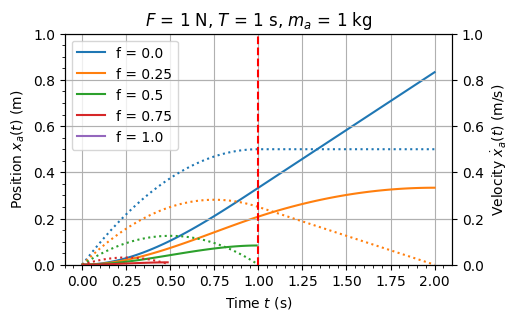

In [108]:
# Define the parameters for plotting
F_val = 1
T_val = 1
m_a_val = 1
f_vals = np.linspace(0, 1, 5)

plt.figure(figsize=(5, 3))
plt.minorticks_on()

ax = plt.gca()
ax_twin = ax.twinx()
for f_val in f_vals:
    # Substitute the parameters into the piecewise function
    x_a_sol_plot = x_a_sol.subs({F: F_val, T: T_val, m_a: m_a_val, f: f_val})
    v_a_sol_plot = v_a_sol.subs({F: F_val, T: T_val, m_a: m_a_val, f: f_val})

    # Create a numerical function for plotting
    x_a_sol_lambdified = sp.lambdify(t, x_a_sol_plot, 'numpy')
    v_a_sol_lambdified = sp.lambdify(t, v_a_sol_plot, 'numpy')

    # Generate time values for plotting
    import numpy as np
    t_vals = np.linspace(0, 2, 100)
    x_a_vals = np.where(v_a_sol_lambdified(t_vals) >= 0, x_a_sol_lambdified(t_vals), np.nan)
    v_a_vals = np.where(v_a_sol_lambdified(t_vals) >= 0, v_a_sol_lambdified(t_vals), np.nan)

    # Plot the piecewise function
    ax.plot(t_vals, x_a_vals, label=f'f = {f_val}')
    ax.set_title(f'$F$ = {F_val} N, $T$ = {T_val} s, $m_a$ = {m_a_val} kg')
    ax.set_xlabel('Time $t$ (s)')
    ax.set_ylabel('Position $x_a(t)$ (m)')
    ax.grid(True)
    
    ax_twin.plot(t_vals, v_a_vals, linestyle=':')
    ax_twin.set_ylabel('Velocity $\dot{x}_a(t)$ (m/s)')
    ax_twin.grid(True)

plt.axvline(x=T_val, color='r', linestyle='--', label='$t = T$')
ax.legend()
ax.set_ylim([0, 1])
ax_twin.set_ylim([0, 1])
plt.show()

## Non dimensionalization

In [109]:
tau, phi, xi_a = sp.symbols('tau, phi, xi_a', positive=True)

In [110]:
xi_a_sol = x_a_sol.subs({
    t: tau*T,
    f: phi*F
})*m_a/(F*(T**2))
xi_a_sol = sp.piecewise_fold(xi_a_sol).simplify().subs({T: 1})
xi_a_sol

Piecewise((tau**2*(-3*phi - tau + 3)/6, tau <= 1), (-phi*tau**2/2 + tau/2 - 1/6, True))

In [111]:
beta_a_sol = xi_a_sol.diff(tau)
beta_a_sol

Piecewise((-tau**2/6 + tau*(-3*phi - tau + 3)/3, tau <= 1), (-phi*tau + 1/2, True))

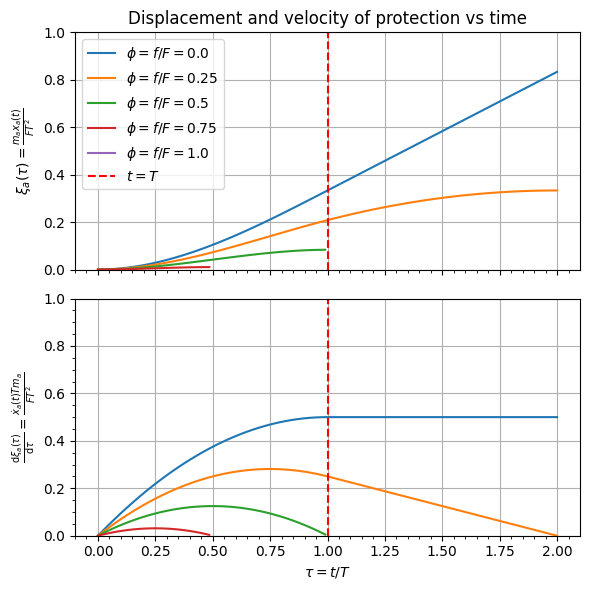

In [112]:
# Define the parameters for plotting
phi_vals = np.linspace(0, 1, 5)


fig, ax_ = plt.subplots(2, 1, figsize=(6, 6), sharex='col')

ax = ax_[0]
ax_twin = ax_[1]
for phi_val in phi_vals:
    # Substitute the parameters into the piecewise function
    xi_a_sol_plot = xi_a_sol.subs({phi: phi_val})
    beta_a_sol_plot = beta_a_sol.subs({phi: phi_val})

    # Create a numerical function for plotting
    xi_a_sol_lambdified = sp.lambdify(tau, xi_a_sol_plot, 'numpy')
    beta_a_sol_lambdified = sp.lambdify(tau, beta_a_sol_plot, 'numpy')

    # Generate time values for plotting
    import numpy as np
    tau_vals = np.linspace(0, 2, 100)
    xi_a_vals = np.where(beta_a_sol_lambdified(tau_vals) >= 0, xi_a_sol_lambdified(tau_vals), np.nan)
    beta_a_vals = np.where(beta_a_sol_lambdified(tau_vals) >= 0, beta_a_sol_lambdified(tau_vals), np.nan)

    # Plot the piecewise function
    ax.plot(tau_vals, xi_a_vals, label=f'$\phi = f/F =${phi_val}')
    ax_twin.set_xlabel(r'$\tau = t/T$')
    ax.set_ylabel(r'$\xi_a(\tau) = \frac{m_a x_a(t)}{F T^2}$')
    ax.grid(True)
    
    ax_twin.plot(tau_vals, beta_a_vals, linestyle='-')
    ax_twin.set_ylabel(r'$\frac{\mathrm{d} \xi_a(\tau)}{\mathrm{d} \tau} = \frac{\dot{x}_a(t) T m_a}{F T^2}$')
    ax_twin.grid(True)

ax.axvline(x=1, color='r', linestyle='--', label='$t = T$')
ax_twin.axvline(x=1, color='r', linestyle='--', label='$t = T$')

ax.set_title('Displacement and velocity vs time')
ax.legend()
ax.set_ylim([0, 1])
ax_twin.set_ylim([0, 1])

ax.set_title('Displacement and velocity of protection vs time')
ax.legend()
# ax.set_ylim([0, 1])
# ax_twin.set_ylim([0, 1])

plt.minorticks_on()

plt.tight_layout()
plt.savefig('protection.pdf')
plt.show()

# Calculate final time and displacement

In [113]:
try:
    from IPython.display import display, clear_output, Math, Markdown
except:
    pass


def print_solutions(solutions):
    ''' print the rendered Latex format in Jupyter cell'''
    for set_num, space in enumerate(solutions):
        latex_str = '\\text{Solution }'
        latex_str += f'{sp.latex(space)}'
        display(Math(latex_str))
        display(Markdown('---'))

## Final time

In [114]:
tau_f_sols = sp.solve(beta_a_sol, tau)
print_solutions(tau_f_sols)

combined = [(pw.args[0][0], pw.args[0][1]) for pw in tau_f_sols if pw]
combined.append((sp.oo, True))
tau_f_sol = sp.simplify(sp.Piecewise(*combined))
tau_f_sol

<IPython.core.display.Math object>

---

<IPython.core.display.Math object>

---

Piecewise((1/(2*phi), phi < 1/2), (2 - 2*phi, True))

## Final displacement

In [115]:
xi_a_sol

Piecewise((tau**2*(-3*phi - tau + 3)/6, tau <= 1), (-phi*tau**2/2 + tau/2 - 1/6, True))

In [116]:
xi_a_f_sol = sp.piecewise_fold(xi_a_sol.subs({tau: tau_f_sol})).as_expr_set_pairs(domain=sp.Interval(0, 1))
xi_a_f_sol = [(expr.simplify(), cond.as_relational(phi)) for expr, cond in xi_a_f_sol]
xi_a_f_sol = sp.Piecewise(*[(expr, cond) for expr, cond in xi_a_f_sol])
xi_a_f_sol

Piecewise((2*(1 - phi)**3/3, (phi >= 1/2) & (phi <= 1)), ((3 - 4*phi)/(24*phi), phi < 1/2))

<lambdifygenerated-7592>:2: RuntimeWarning: divide by zero encountered in divide
  return select([less(phi, 1/2),True], [(1/2)/phi,2 - 2*phi], default=nan)
<lambdifygenerated-7593>:2: RuntimeWarning: divide by zero encountered in divide
  return select([logical_and.reduce((greater_equal(phi, 1/2),less_equal(phi, 1))),less(phi, 1/2)], [(2/3)*(1 - phi)**3,(1/24)*(3 - 4*phi)/phi], default=nan)


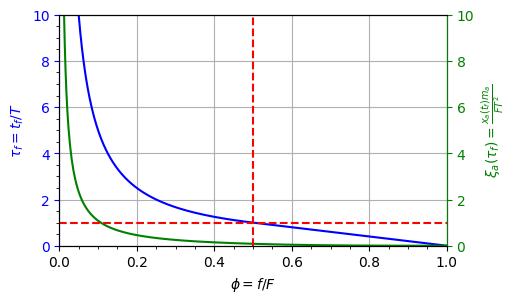

In [117]:
plt.figure(figsize=(5, 3))
plt.minorticks_on()

ax = plt.gca()
ax_twin = ax.twinx()

# Substitute the parameters into the piecewise function
tau_f_plot = tau_f_sol
xi_a_f_plot = xi_a_f_sol

# Create a numerical function for plotting
tau_f_sol_lambdified = sp.lambdify(phi, tau_f_plot, 'numpy')
xi_a_f_plot_lambdified = sp.lambdify(phi, xi_a_f_plot, 'numpy')

# Generate time values for plotting
phi_vals = np.linspace(0, 1, 500)
tau_f_vals = tau_f_sol_lambdified(phi_vals)
xi_a_f_vals = xi_a_f_plot_lambdified(phi_vals)

# Plot the piecewise function
ax.plot(phi_vals, tau_f_vals, color='blue')  # Left axis plot in blue
ax_twin.plot(phi_vals, xi_a_f_vals, color='green')  # Right axis plot in green
ax.set_xlabel(r'$\phi = f/F$')
ax.set_ylabel(r'$\tau_f = t_f/T$')
ax_twin.set_ylabel(r'$\xi_a(\tau_f) = \frac{x_a(t_f) m_a}{F T^2}$')
ax.grid(True)

# Customize axis colors
ax.spines['left'].set_color('blue')
ax.yaxis.label.set_color('blue')
ax.tick_params(axis='y', colors='blue')

ax_twin.spines['right'].set_color('green')
ax_twin.yaxis.label.set_color('green')
ax_twin.tick_params(axis='y', colors='green')

plt.axvline(x=1/2, color='r', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--')
# ax.legend()
ax.set_ylim([0, 10])
ax_twin.set_ylim([0, 10])
ax.set_xlim([0, 1])
plt.show()


# Motion of the structure

In [118]:
m_s, c_s, k_s, t_f = sp.symbols('m_s c_s k_s t_f', positive=True, real=True)
x_s = sp.Function('x_s')(t)
x_s

x_s(t)

In [119]:
# Define the differential equation for t <= t_f
eq_s1 = sp.Eq(m_s * x_s.diff(t, t) + x_s*k_s + x_s.diff(t) * c_s, f)
eq_s1

Eq(c_s*Derivative(x_s(t), t) + k_s*x_s(t) + m_s*Derivative(x_s(t), (t, 2)), f)

In [120]:
# Solve the differential equation for t <= t_f
sol_s1 = sp.dsolve(eq_s1, ics={x_s.subs(t, 0): 0, x_s.diff(t).subs(t, 0): 0})

# Extract the position function for t < T
x_s_sol1 = sp.simplify(sol_s1.rhs)
x_s_sol1

f*((c_s - sqrt(c_s**2 - 4*k_s*m_s))*sqrt(c_s**2 - 4*k_s*m_s)*exp(t*(c_s - sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - (c_s + sqrt(c_s**2 - 4*k_s*m_s))*sqrt(c_s**2 - 4*k_s*m_s)*exp(t*(c_s + sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) + 2*(c_s**2 - 4*k_s*m_s)*exp(c_s*t/m_s))*exp(-c_s*t/m_s)/(2*k_s*(c_s**2 - 4*k_s*m_s))

In [121]:
# Define the differential equation for t > t_f

# No cohesion
eq_s2_nc = sp.Eq(m_s * x_s.diff(t, t) + x_s*k_s + x_s.diff(t) * c_s, 0)
eq_s2_nc

Eq(c_s*Derivative(x_s(t), t) + k_s*x_s(t) + m_s*Derivative(x_s(t), (t, 2)), 0)

In [122]:
# With cohesion
eq_s2_wc = sp.Eq(m_s * x_s.diff(t, t) + x_s*k_s + x_s.diff(t) * c_s, -f)
eq_s2_wc

Eq(c_s*Derivative(x_s(t), t) + k_s*x_s(t) + m_s*Derivative(x_s(t), (t, 2)), -f)

In [123]:
# Solve the differential equation for t > t_f with no cohesion
sol_s2_nc = sp.dsolve(eq_s2_nc, ics={x_s.subs(t, t_f): x_s_sol1.subs(t, t_f), 
                               x_s.diff(t).subs(t, t_f): x_s_sol1.diff(t).subs(t, t_f)})

# Extract the position function for t < T
x_s_sol2_nc = sol_s2_nc.rhs.simplify()
x_s_sol2_nc

f*(-(1 - exp(t_f*(c_s + sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)))*(-c_s + sqrt(c_s**2 - 4*k_s*m_s))*(c_s**2 - 4*k_s*m_s)*exp((t*(c_s - sqrt(c_s**2 - 4*k_s*m_s))/2 + 5*t_f*sqrt(c_s**2 - 4*k_s*m_s))/m_s) + sqrt(c_s**2 - 4*k_s*m_s)*(c_s**2*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - c_s**2*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s) + c_s*sqrt(c_s**2 - 4*k_s*m_s)*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - c_s*sqrt(c_s**2 - 4*k_s*m_s)*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s) - 4*k_s*m_s*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) + 4*k_s*m_s*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s))*exp(t*(c_s + sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)))*exp(-(c_s*t + 5*t_f*sqrt(c_s**2 - 4*k_s*m_s))/m_s)/(2*k_s*(c_s**2 - 4*k_s*m_s)**(3/2))

In [124]:
# Solve the differential equation for t > t_f with cohesion
sol_s2_wc = sp.dsolve(eq_s2_wc, ics={x_s.subs(t, t_f): x_s_sol1.subs(t, t_f), 
                               x_s.diff(t).subs(t, t_f): x_s_sol1.diff(t).subs(t, t_f)})

# Extract the position function for t < T
x_s_sol2_wc = sol_s2_wc.rhs.simplify()
x_s_sol2_wc

f*((-c_s + sqrt(c_s**2 - 4*k_s*m_s))*(c_s**2 - 4*k_s*m_s)*(2*exp(t_f*(c_s + sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - 1)*exp((t*(c_s - sqrt(c_s**2 - 4*k_s*m_s))/2 + 5*t_f*sqrt(c_s**2 - 4*k_s*m_s))/m_s) - 2*(c_s**2 - 4*k_s*m_s)**(3/2)*exp((c_s*t + 5*t_f*sqrt(c_s**2 - 4*k_s*m_s))/m_s) + sqrt(c_s**2 - 4*k_s*m_s)*(2*c_s**2*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - c_s**2*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s) + 2*c_s*sqrt(c_s**2 - 4*k_s*m_s)*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - c_s*sqrt(c_s**2 - 4*k_s*m_s)*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s) - 8*k_s*m_s*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) + 4*k_s*m_s*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s))*exp(t*(c_s + sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)))*exp(-(c_s*t + 5*t_f*sqrt(c_s**2 - 4*k_s*m_s))/m_s)/(2*k_s*(c_s**2 - 4*k_s*m_s)**(3/2))

In [125]:
# Combine the solutions into a piecewise function
x_s_sol_nc = sp.piecewise_fold(sp.Piecewise((x_s_sol1, t <= t_f), (x_s_sol2_nc, t > t_f))).simplify()

# Display the piecewise solution
x_s_sol_nc

Piecewise((f*((c_s - sqrt(c_s**2 - 4*k_s*m_s))*sqrt(c_s**2 - 4*k_s*m_s)*exp(t*(c_s - sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - (c_s + sqrt(c_s**2 - 4*k_s*m_s))*sqrt(c_s**2 - 4*k_s*m_s)*exp(t*(c_s + sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) + 2*(c_s**2 - 4*k_s*m_s)*exp(c_s*t/m_s))*exp(-c_s*t/m_s)/(2*k_s*(c_s**2 - 4*k_s*m_s)), t <= t_f), (f*(-(c_s - sqrt(c_s**2 - 4*k_s*m_s))*(c_s**2 - 4*k_s*m_s)*(exp(t_f*(c_s + sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - 1)*exp((t*(c_s - sqrt(c_s**2 - 4*k_s*m_s)) + 10*t_f*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) + sqrt(c_s**2 - 4*k_s*m_s)*(c_s**2*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - c_s**2*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s) + c_s*sqrt(c_s**2 - 4*k_s*m_s)*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - c_s*sqrt(c_s**2 - 4*k_s*m_s)*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s) - 4*k_s*m_s*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) + 4*k_s*m_s*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s))*exp(t*(c_s + sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)))*exp(-(c_s*t + 5*t_f

In [126]:
# Combine the solutions into a piecewise function
x_s_sol_wc = sp.piecewise_fold(sp.Piecewise((x_s_sol1, t <= t_f), (x_s_sol2_wc, t > t_f))).simplify()

# Display the piecewise solution
x_s_sol_wc

Piecewise((f*((c_s - sqrt(c_s**2 - 4*k_s*m_s))*sqrt(c_s**2 - 4*k_s*m_s)*exp(t*(c_s - sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - (c_s + sqrt(c_s**2 - 4*k_s*m_s))*sqrt(c_s**2 - 4*k_s*m_s)*exp(t*(c_s + sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) + 2*(c_s**2 - 4*k_s*m_s)*exp(c_s*t/m_s))*exp(-c_s*t/m_s)/(2*k_s*(c_s**2 - 4*k_s*m_s)), t <= t_f), (-f*((c_s - sqrt(c_s**2 - 4*k_s*m_s))*(c_s**2 - 4*k_s*m_s)*(2*exp(t_f*(c_s + sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - 1)*exp((t*(c_s - sqrt(c_s**2 - 4*k_s*m_s)) + 10*t_f*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) + 2*(c_s**2 - 4*k_s*m_s)**(3/2)*exp((c_s*t + 5*t_f*sqrt(c_s**2 - 4*k_s*m_s))/m_s) - sqrt(c_s**2 - 4*k_s*m_s)*(2*c_s**2*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - c_s**2*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s) + 2*c_s*sqrt(c_s**2 - 4*k_s*m_s)*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) - c_s*sqrt(c_s**2 - 4*k_s*m_s)*exp(5*t_f*sqrt(c_s**2 - 4*k_s*m_s)/m_s) - 8*k_s*m_s*exp(t_f*(c_s + 9*sqrt(c_s**2 - 4*k_s*m_s))/(2*m_s)) + 4*k_s*m_s*exp(5*t_f*sqrt(c_s**2

## Non dimensionalization

In [127]:
tau_s, omega_s, zeta_s, phi_s, tau_s_f = sp.symbols('tau_s, omega_s, zeta_s, phi_s, tau_s_f', positive=True, real=True)

In [128]:
xi_s_sol_nc = x_s_sol_nc.subs({
    t: tau_s/omega_s,
    t_f: tau_s_f/omega_s,
    m_s: k_s/(omega_s**2),
    c_s: zeta_s*(2*m_s*omega_s)
})/(f/k_s)

xi_s_sol_nc = sp.piecewise_fold(xi_s_sol_nc.simplify(assumption=sp.Lt(1 - zeta_s**2, 1))).subs({omega_s: 1}).simplify()
xi_s_sol_nc

Piecewise((((zeta_s - sqrt(zeta_s**2 - 1))*sqrt(zeta_s**2 - 1)*exp(tau_s*(zeta_s - sqrt(zeta_s**2 - 1))) - (zeta_s + sqrt(zeta_s**2 - 1))*sqrt(zeta_s**2 - 1)*exp(tau_s*(zeta_s + sqrt(zeta_s**2 - 1))) + 2*(zeta_s**2 - 1)*exp(2*tau_s*zeta_s))*exp(-2*tau_s*zeta_s)/(2*(zeta_s**2 - 1)), tau_s <= tau_s_f), (((1 - exp(tau_s_f*(zeta_s + sqrt(zeta_s**2 - 1))))*(zeta_s - sqrt(zeta_s**2 - 1))*(zeta_s**2 - 1)*exp(tau_s*(zeta_s - sqrt(zeta_s**2 - 1)) + 10*tau_s_f*sqrt(zeta_s**2 - 1)) + sqrt(zeta_s**2 - 1)*(zeta_s**2*exp(tau_s_f*(zeta_s + 9*sqrt(zeta_s**2 - 1))) - zeta_s**2*exp(10*tau_s_f*sqrt(zeta_s**2 - 1)) + zeta_s*sqrt(zeta_s**2 - 1)*exp(tau_s_f*(zeta_s + 9*sqrt(zeta_s**2 - 1))) - zeta_s*sqrt(zeta_s**2 - 1)*exp(10*tau_s_f*sqrt(zeta_s**2 - 1)) - exp(tau_s_f*(zeta_s + 9*sqrt(zeta_s**2 - 1))) + exp(10*tau_s_f*sqrt(zeta_s**2 - 1)))*exp(tau_s*(zeta_s + sqrt(zeta_s**2 - 1))))*exp(-2*tau_s*zeta_s - 10*tau_s_f*sqrt(zeta_s**2 - 1))/(2*(zeta_s**2 - 1)**(3/2)), True))

In [129]:
xi_s_sol_wc = x_s_sol_wc.subs({
    t: tau_s/omega_s,
    t_f: tau_s_f/omega_s,
    m_s: k_s/(omega_s**2),
    c_s: zeta_s*(2*m_s*omega_s)
})/(f/k_s)

xi_s_sol_wc = sp.piecewise_fold(xi_s_sol_wc.simplify(assumption=sp.Lt(1 - zeta_s**2, 1))).subs({omega_s: 1}).simplify()
xi_s_sol_wc

Piecewise((((zeta_s - sqrt(zeta_s**2 - 1))*sqrt(zeta_s**2 - 1)*exp(tau_s*(zeta_s - sqrt(zeta_s**2 - 1))) - (zeta_s + sqrt(zeta_s**2 - 1))*sqrt(zeta_s**2 - 1)*exp(tau_s*(zeta_s + sqrt(zeta_s**2 - 1))) + 2*(zeta_s**2 - 1)*exp(2*tau_s*zeta_s))*exp(-2*tau_s*zeta_s)/(2*(zeta_s**2 - 1)), tau_s <= tau_s_f), ((-(zeta_s - sqrt(zeta_s**2 - 1))*(zeta_s**2 - 1)*(2*exp(tau_s_f*(zeta_s + sqrt(zeta_s**2 - 1))) - 1)*exp(tau_s*(zeta_s - sqrt(zeta_s**2 - 1)) + 10*tau_s_f*sqrt(zeta_s**2 - 1)) - 2*(zeta_s**2 - 1)**(3/2)*exp(2*tau_s*zeta_s + 10*tau_s_f*sqrt(zeta_s**2 - 1)) + sqrt(zeta_s**2 - 1)*(2*zeta_s**2*exp(tau_s_f*(zeta_s + 9*sqrt(zeta_s**2 - 1))) - zeta_s**2*exp(10*tau_s_f*sqrt(zeta_s**2 - 1)) + 2*zeta_s*sqrt(zeta_s**2 - 1)*exp(tau_s_f*(zeta_s + 9*sqrt(zeta_s**2 - 1))) - zeta_s*sqrt(zeta_s**2 - 1)*exp(10*tau_s_f*sqrt(zeta_s**2 - 1)) - 2*exp(tau_s_f*(zeta_s + 9*sqrt(zeta_s**2 - 1))) + exp(10*tau_s_f*sqrt(zeta_s**2 - 1)))*exp(tau_s*(zeta_s + sqrt(zeta_s**2 - 1))))*exp(-2*tau_s*zeta_s - 10*tau_s_f*sqrt(

In [130]:
beta_s_sol_nc = xi_s_sol_nc.diff(tau_s).simplify()
beta_s_sol_nc

Piecewise(((exp(2*tau_s*sqrt(zeta_s**2 - 1)) - 1)*exp(-tau_s*(zeta_s + sqrt(zeta_s**2 - 1)))/(2*sqrt(zeta_s**2 - 1)), tau_s <= tau_s_f), ((exp(tau_s_f*(zeta_s + 2*sqrt(zeta_s**2 - 1))) - exp(tau_s_f*sqrt(zeta_s**2 - 1)) + exp((2*tau_s + tau_s_f)*sqrt(zeta_s**2 - 1)) - exp(2*tau_s*sqrt(zeta_s**2 - 1) + tau_s_f*zeta_s))*exp(-tau_s*zeta_s - tau_s*sqrt(zeta_s**2 - 1) - tau_s_f*sqrt(zeta_s**2 - 1))/(2*sqrt(zeta_s**2 - 1)), True))

In [131]:
beta_s_sol_wc = xi_s_sol_wc.diff(tau_s).simplify()
beta_s_sol_wc

Piecewise(((exp(2*tau_s*sqrt(zeta_s**2 - 1)) - 1)*exp(-tau_s*(zeta_s + sqrt(zeta_s**2 - 1)))/(2*sqrt(zeta_s**2 - 1)), tau_s <= tau_s_f), ((exp(tau_s_f*(zeta_s + 2*sqrt(zeta_s**2 - 1))) - exp(tau_s_f*sqrt(zeta_s**2 - 1))/2 + exp((2*tau_s + tau_s_f)*sqrt(zeta_s**2 - 1))/2 - exp(2*tau_s*sqrt(zeta_s**2 - 1) + tau_s_f*zeta_s))*exp(-tau_s*zeta_s - tau_s*sqrt(zeta_s**2 - 1) - tau_s_f*sqrt(zeta_s**2 - 1))/sqrt(zeta_s**2 - 1), True))

c:\TRABAJO\CONICET\venvs\car_models\lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


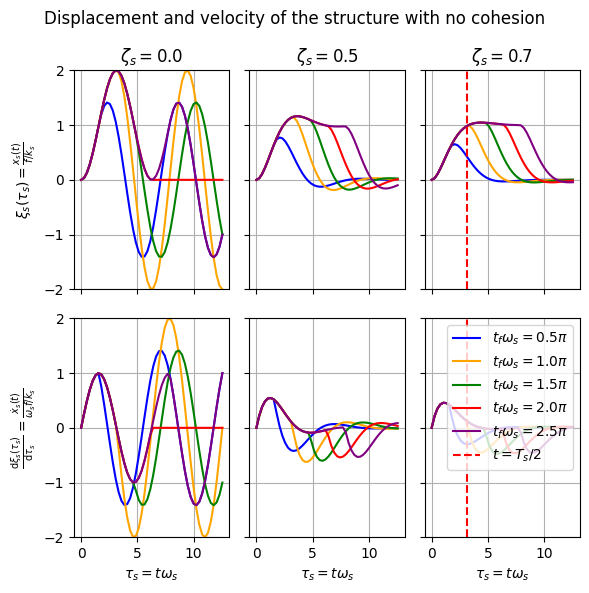

In [132]:
def plot_structure_responses(cohesion: bool, tau_s_f_vals=None):
    zeta_s_vals = [.0, 0.5, .7]

    fig, ax_ = plt.subplots(2,len(zeta_s_vals), figsize=(6, 6), sharex='col', sharey='row')
    ax = ax_[0, :]
    ax_twin = ax_[1, :]

    tau_s_f_vals = np.linspace(np.pi/2, (10/4)*np.pi, 5) if tau_s_f_vals is None else tau_s_f_vals
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    for i_zeta_s, zeta_s_val in enumerate(zeta_s_vals):
        ax[i_zeta_s].set_title(f'$\zeta_s = {zeta_s_val}$')
        for i_tau_s_f, tau_s_f_val in enumerate(tau_s_f_vals):
            # Substitute the parameters into the piecewise function
            if cohesion:
                xi_s_sol_plot = (xi_s_sol_wc.subs({tau_s_f: tau_s_f_val, zeta_s: zeta_s_val}))
                beta_s_sol_plot = (beta_s_sol_wc.subs({tau_s_f: tau_s_f_val, zeta_s: zeta_s_val}))
            else:
                xi_s_sol_plot = (xi_s_sol_nc.subs({tau_s_f: tau_s_f_val, zeta_s: zeta_s_val}))
                beta_s_sol_plot = (beta_s_sol_nc.subs({tau_s_f: tau_s_f_val, zeta_s: zeta_s_val}))

            # Create a numerical function for plotting
            xi_s_sol_lambdified = sp.lambdify(tau_s, xi_s_sol_plot, 'numpy')
            beta_s_sol_lambdified = sp.lambdify(tau_s, beta_s_sol_plot, 'numpy')

            # Generate time values for plotting
            tau_s_vals = np.linspace(0, 4*np.pi, 50)
            xi_s_vals = xi_s_sol_lambdified(tau_s_vals)  
            beta_s_vals = beta_s_sol_lambdified(tau_s_vals)  

            # Plot the piecewise function
            ax[i_zeta_s].plot(tau_s_vals, np.real(xi_s_vals), color=colors[i_tau_s_f])
            # ax[i_zeta_s].plot(tau_s_vals, np.imag(xi_s_vals), color=colors[i_tau_s_f], linestyle=':')
            ax_twin[i_zeta_s].set_xlabel(r'$\tau_s = t \omega_s$')
            if i_zeta_s == 0:
                ax[i_zeta_s].set_ylabel(r'$\xi_s(\tau_s) = \frac{x_s(t)}{f/k_s}$')
            ax[i_zeta_s].grid(True)
            
            ax_twin[i_zeta_s].plot(tau_s_vals, beta_s_vals, linestyle='-', label=f'$t_f \omega_s ={tau_s_f_val/np.pi}\pi$',
                                color=colors[i_tau_s_f])
            if i_zeta_s == 0:
                ax_twin[i_zeta_s].set_ylabel(r'$\frac{\mathrm{d}\xi_s(\tau_s)}{\mathrm{d}\tau_s} = \frac{\dot{x}_s(t)}{\omega_s f/k_s}$')
            ax_twin[i_zeta_s].grid(True)

    fig.suptitle(f'Displacement and velocity of the structure with {"no " if not cohesion else ""}cohesion')
    ax[i_zeta_s].axvline(x=np.pi, linestyle='--', color='red')
    ax_twin[i_zeta_s].axvline(x=np.pi, linestyle='--', color='red', label='$t=T_s/2$')
    ax[i_zeta_s].set_ylim([-2, 2])
    ax_twin[i_zeta_s].set_ylim([-2, 2])
    ax_twin[i_zeta_s].legend()

    plt.tight_layout()
    plt.savefig(f'structure_{"wc" if cohesion else "nc"}.pdf')
    plt.show()

plot_structure_responses(cohesion=False)

c:\TRABAJO\CONICET\venvs\car_models\lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


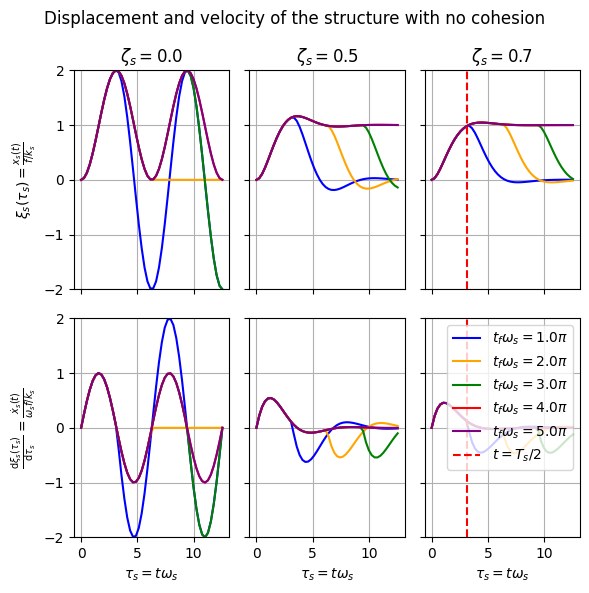

In [133]:
plot_structure_responses(cohesion=False, tau_s_f_vals=np.linspace(np.pi, 5*np.pi, 5))

c:\TRABAJO\CONICET\venvs\car_models\lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


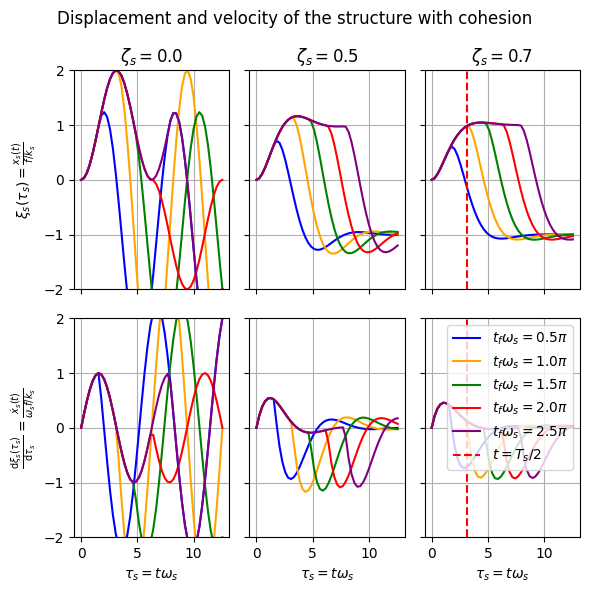

In [134]:
plot_structure_responses(cohesion=True)

## Time of max displacement in the structure

In [135]:
def xi_s_sol_lambdified(zeta_s_val, tau_s_f_val, cohesion: bool):
    if cohesion:
        xi_s_sol_sub = xi_s_sol_wc.subs({zeta_s: zeta_s_val, tau_s_f: tau_s_f_val})
    else:
        xi_s_sol_sub = xi_s_sol_nc.subs({zeta_s: zeta_s_val, tau_s_f: tau_s_f_val})

    xi_s_calc = sp.lambdify(tau_s, sp.re(xi_s_sol_sub))
    return xi_s_calc


def xi_s_max_lambdified(zeta_s_val: float, tau_s_f_val: float, cohesion: bool, tol_tau_s: float = 1e-3):
    """
    Finds the maximum value of the real part of the solution `xi_s_sol` within a specified range for the variable `tau_s`.
    The function iterates over values of `tau_s` starting from 0, incrementing by `tol_tau_s` up to a maximum value determined 
    by `2 * tau_s_f_val` or `π`, whichever is larger. For each value of `tau_s`, the real part of the solution `xi_s_sol` is 
    evaluated using the provided `zeta_s_val` and `tau_s_f_val`. The function stops and returns the maximum value when a 
    decrease is detected. If no decrease is found, `np.nan` is returned.
    
    Parameters
    ----------
    zeta_s_val : float
        The value to substitute for the parameter `zeta_s` in the solution `xi_s_sol`.
    tau_s_f_val : float
        The value to substitute for the parameter `tau_s_f` in the solution `xi_s_sol`.
    tol_tau_s : float, optional
        The step size to increment `tau_s` in the search for the maximum value (default is 0.01).
    
    Returns
    -------
    float
        The maximum value of the real part of `xi_s_sol` up to the point where it starts decreasing. 
        Returns `np.nan` if no maximum is found.
    
    Notes
    -----
    - The function uses `sp.lambdify` to convert the symbolic expression `xi_s_sol` to a numerical function of `tau_s`.
    - It compares the real part of the solution at each step to determine the maximum value.
    - `xi_s_sol` is expected to be a symbolic expression involving `zeta_s`, `tau_s_f`, and `tau_s`.
    """
    tau_s_vals = np.arange(tol_tau_s, max(2 * tau_s_f_val, np.pi), tol_tau_s)
    
    xi_s_sol_lambdified_ = xi_s_sol_lambdified(zeta_s_val, tau_s_f_val, cohesion)
    xi_s_vals = xi_s_sol_lambdified_(tau_s_vals)
    
    # Calculate the differences and find the first change in sign
    slopes = np.diff(xi_s_vals)
    sign_changes = np.where(np.diff(np.sign(slopes)))[0]
    
    if len(sign_changes) > 0:
        first_change_idx = sign_changes[0]
        return float(xi_s_vals[first_change_idx])
    else:
        return np.nan


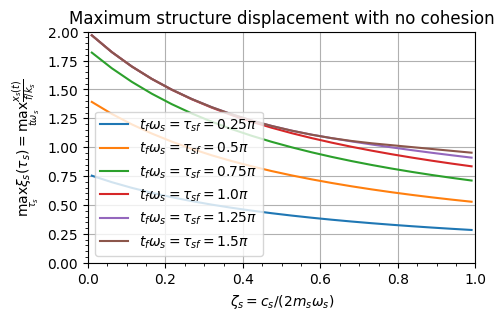

In [136]:

def plot_structure_max_displacement(cohesion):
    fig, ax = plt.subplots(1, 1, figsize=(5, 3))
    zeta_s_values = np.linspace(.01, .99, 20)
    tau_s_f_values = np.linspace(.25*np.pi, 1.5*np.pi, 6)
    plt.minorticks_on()
    for tau_s_f_val in tau_s_f_values:
        xi_s_max_values = []
        for zeta_s_val in zeta_s_values:
            xi_s_max_values.append(xi_s_max_lambdified(zeta_s_val, tau_s_f_val, cohesion))
        ax.plot(zeta_s_values, xi_s_max_values, 
                label=r'$t_f \omega_s = \tau_{sf}=$' + f'{tau_s_f_val/np.pi}' + r'$\pi$')

    ax.set_xlim([0,1])
    ax.set_ylim([0,2])
    ax.set_xlabel(r'$\zeta_s = c_s / (2 m_s \omega_s)$')
    ax.set_ylabel(r'$\max_{\tau_s} \xi_s(\tau_s) = \max_{t\omega_s} \frac{x_s(t)} {f/k_s}$')
    ax.set_title(f'Maximum structure displacement with {"no " if not cohesion else ""}cohesion')
    ax.legend(loc='lower left')
    plt.grid(True)
    plt.show()

plot_structure_max_displacement(cohesion=False)

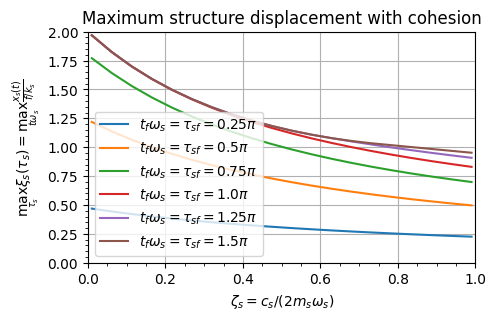

In [137]:
plot_structure_max_displacement(cohesion=True)

# Optimization of $f$

## Solve $\xi_{af}$ for $\phi$

In [138]:
xi_a_f = sp.symbols('xi_a_f', real=True, positive=True)

In [139]:
xi_a_eq = sp.Eq(xi_a_f, xi_a_f_sol)
xi_a_eq

Eq(xi_a_f, Piecewise((2*(1 - phi)**3/3, (phi >= 1/2) & (phi <= 1)), ((3 - 4*phi)/(24*phi), phi < 1/2)))

In [140]:
phi_sols = sp.solve(xi_a_eq, phi)
print_solutions(phi_sols)

combined = []
for pw in phi_sols:
    if pw:
        expr, cond = pw.args[0]
        simplified_expr = expr.simplify()
        if isinstance(cond, sp.And):
            collected_cond = sp.And(*[c.collect(xi_a_f) if hasattr(c, 'collect') else c for c in cond.args])
        else:
            collected_cond = cond.collect(xi_a_f) if hasattr(cond, 'collect') else cond
        combined.append((simplified_expr, collected_cond))
# combined.append((0, True))
phi_sol = sp.Piecewise(*combined).simplify()
phi_sol

<IPython.core.display.Math object>

---

<IPython.core.display.Math object>

---

Piecewise((3/(4*(6*xi_a_f + 1)), 1/(6*xi_a_f + 1) < 2/3), (-2**(2/3)*3**(1/3)*xi_a_f**(1/3)/2 + 1, 2**(2/3)*3**(1/3)*xi_a_f**(1/3) <= 1))

In [141]:
phi_sol_set_pairs = phi_sol.as_expr_set_pairs()
phi_sol = sp.Piecewise(*[(expr.simplify(), cond) for expr, cond in 
                            [(expr.simplify(), cond.as_relational(xi_a_f)) for expr, cond in phi_sol_set_pairs]])
phi_sol

Piecewise((3/(4*(6*xi_a_f + 1)), xi_a_f > 1/12), (-2**(2/3)*3**(1/3)*xi_a_f**(1/3)/2 + 1, True))

## $\tau_f$ as a function of $\xi_{af}$ 

In [142]:
tau_f_sol

Piecewise((1/(2*phi), phi < 1/2), (2 - 2*phi, True))

In [143]:
tau_f = sp.piecewise_exclusive(sp.piecewise_fold(tau_f_sol.subs({phi: phi_sol}))).simplify()
tau_f = sp.Piecewise(*[(expr.simplify(), cond) for expr, cond in 
                            [(expr.simplify(), cond.as_relational(xi_a_f)) for expr, cond in tau_f.as_expr_set_pairs()]])
tau_f

Piecewise((4*xi_a_f + 2/3, xi_a_f > 1/12), (2**(2/3)*3**(1/3)*xi_a_f**(1/3), True))

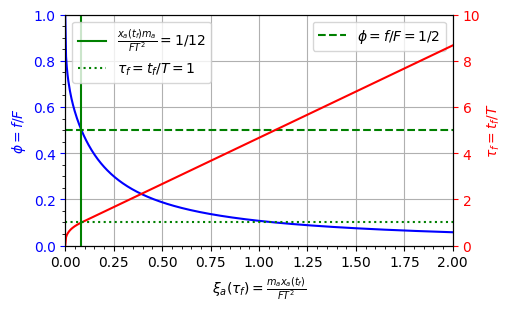

In [144]:
plt.figure(figsize=(5, 3))
plt.minorticks_on()

ax = plt.gca()
ax_twin = plt.twinx(ax)

# Substitute the parameters into the piecewise function
phi_sol_plot = phi_sol
tau_f_plot = tau_f

# Create a numerical function for plotting
phi_sol_lambdified = sp.lambdify(xi_a_f, phi_sol_plot, 'numpy')
tau_f_lambdified = sp.lambdify(xi_a_f, tau_f_plot, 'numpy')

# Generate time values for plotting
xi_a_f_vals = np.linspace(0, 2, 500)
phi_vals = phi_sol_lambdified(xi_a_f_vals)
tau_f_vals = tau_f_lambdified(xi_a_f_vals)

# Plot the piecewise function
ax.plot(xi_a_f_vals, phi_vals, color='blue')  # Left axis plot in blue
ax_twin.plot(xi_a_f_vals, tau_f_vals, color='red')  # Right axis plot in red
ax.set_ylabel(r'$\phi = f/F$')
ax_twin.set_ylabel(r'$\tau_f = t_f/T$')
ax.set_xlabel(r'$\xi_a(\tau_f) = \frac{m_a x_{a}(t_f)}{F T^2}$')
ax.grid(True)

ax.set_xlim([0, 2])
ax.set_ylim([0, 1])
ax_twin.set_ylim([0, 10])

# Guide lines
ax_twin.axvline(x=1/12, color='g', linestyle='-', label=r'$\frac{x_{a}(t_f) m_a}{F T^2}=1/12$')
ax.axhline(y=1/2, color='g', linestyle='--', label=r'$\phi = f / F = 1/2$')
ax_twin.axhline(y=1, color='g', linestyle=':', label=r'$\tau_f = t_f / T = 1$')

ax.legend(loc='upper right')
ax_twin.legend(loc='upper left')

# Customize axis colors
ax.yaxis.label.set_color('blue')
ax.tick_params(axis='y', colors='blue')
ax_twin.yaxis.label.set_color('red')
ax_twin.tick_params(axis='y', colors='red')
plt.show()


## Optimum $f$ assuming $\xi_s(t)=0$

In [145]:
from typing import Tuple


def f_t_f_opt(F: float, T: float, m_a: float, x_a_f: float) -> Tuple[float, float]:
    xi_a_f = x_a_f*m_a/(F * (T**2))
    f = F * phi_sol_lambdified(xi_a_f)
    t_f = T*tau_f_lambdified(xi_a_f)
    return (f, t_f)

## Optimum $f$ assuming $$t_f = \arg\max_{t} (x_a(t) - x_s(t)): \dot{x}_a(t_f) = 0$$

In [146]:
def x_s_max(m_s_: float, c_s_: float, k_s_: float, t_f_: float, f_: float, cohesion: bool) -> float:
    omega_s_ = np.sqrt(k_s_/m_s_)
    zeta_s_val = c_s_/(2*omega_s_*m_s_)
    tau_s_f_val = t_f_ * omega_s_
    xi_s_max = xi_s_max_lambdified(zeta_s_val, tau_s_f_val, cohesion)
    return xi_s_max*(f_/k_s_)

## Iterative approximation of optimum $f$

In [147]:
def iter_opt(n_iter: int, k_s_: float, c_s_: float, m_s_: float, F_: float, T_: float, m_a_: float, d_c_: float, 
             cohesion: bool, x_s_f_: float = 1e-6, 
             f_: float = 1e-6, verbose: bool = True):
    t_f_ = 10*T_
    x_s_f_list, x_a_f_list, t_f_list, f_list = [], [], [], []
    for i in range(n_iter):
        x_a_f_ = d_c_ + x_s_f_
        x_s_max_ = x_s_max(m_s_, c_s_, k_s_, t_f_, f_, cohesion) if t_f_ > T_ else np.nan
        if verbose:
            print(f'{x_s_f_=:4f}, {x_a_f_=:4f}, {(x_a_f_-x_s_f_)=:4f}, {t_f_=:4f}, {f_=:4f}, {x_s_max_=:4f}')
        f_, t_f_ = f_t_f_opt(F=F_, T=T_, m_a=m_a_, x_a_f=x_a_f_)
        x_s_f_ = x_s_max(m_s_, c_s_, k_s_, t_f_, f_, cohesion)
        x_s_f_list.append(x_s_f_)
        x_a_f_list.append(x_a_f_)
        t_f_list.append(t_f_)
        f_list.append(f_)
    return x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_


In [199]:
class IterOptResults:
    def __init__(self, x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_):
        self.x_s_f_list = x_s_f_list
        self.x_a_f_list = x_a_f_list
        self.t_f_list = t_f_list
        self.f_list = f_list
        self.x_s_max_ = x_s_max_

    def plot(self, d_c_):
        fig, ax = plt.subplots(2, 1, figsize=(6,6), sharex='col')
        plt.minorticks_on()

        ax[0].plot(self.x_a_f_list, label=r'$x_{af}$')
        ax[0].plot(self.x_s_f_list, label=r'$x_{sf}$')
        ax[0].plot(np.array(self.x_a_f_list) - np.array(self.x_s_f_list), label=r'$x_{af} - x_{sf}$')
        ax[0].axhline(y=d_c_, color='black', linestyle='--', label=r'$d_c$')
        ax[0].set_ylabel('displacements (m)')
        ax[0].legend()
        ax[0].grid()

        ax[1].plot(self.t_f_list, label=r'$t_f$', color='b')
        ax[1].set_ylabel(r'$t_f$ (s)')
        ax[1].yaxis.label.set_color('blue')
        ax[1].tick_params(axis='y', colors='blue')
        ax[1].set_ylim([0, 1.1*max(self.t_f_list)])
        ax[1].grid()

        ax_twin = plt.twinx(ax[1])
        ax_twin.plot(self.f_list, label=r'$f$', color='r')
        ax_twin.set_ylabel(r'$f$ (N)')
        ax_twin.yaxis.label.set_color('red')
        ax_twin.tick_params(axis='y', colors='red')
        ax_twin.set_ylim([0, 1.1*max(self.f_list)])
        ax[1].set_xlabel('iteration')
        plt.show()

class FullIter:
    def __init__(self, k_s_, m_s_, c_s_, cohesion, brick_area, F_, T_, m_a_, d_c_, x_s_max_hf, iter_opt_results):
        self.k_s_ = k_s_
        self.m_s_ = m_s_
        self.c_s_ = c_s_
        self.cohesion = cohesion
        self.brick_area = brick_area
        self.F_ = F_
        self.T_ = T_
        self.m_a_ = m_a_
        self.d_c_ = d_c_
        self.x_s_max_hf = x_s_max_hf
        self.iter_opt_results = iter_opt_results


# Hypothesis: Max pressure applied to all the area

In [200]:
full_iters_max_press = []

### full_iter = 0

m_a_=12.660480000000002 kg
Loading: F_=5322676.007542 N, T_=0.000137 s
Baseline: x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=0.029325 m
x_s_f_=0.000001, x_a_f_=0.100001, (x_a_f_-x_s_f_)=0.100000, t_f_=0.001370, f_=0.000001, x_s_max_=0.000000
x_s_f_=0.026089, x_a_f_=0.126089, (x_a_f_-x_s_f_)=0.100000, t_f_=0.007039, f_=51783.258941, x_s_max_=0.026089
x_s_f_=0.024370, x_a_f_=0.124370, (x_a_f_-x_s_f_)=0.100000, t_f_=0.008851, f_=41179.694574, x_s_max_=0.024370
x_s_f_=0.024491, x_a_f_=0.124491, (x_a_f_-x_s_f_)=0.100000, t_f_=0.008731, f_=41743.101213, x_s_max_=0.024491
x_s_f_=0.024483, x_a_f_=0.124483, (x_a_f_-x_s_f_)=0.100000, t_f_=0.008740, f_=41702.779359, x_s_max_=0.024483


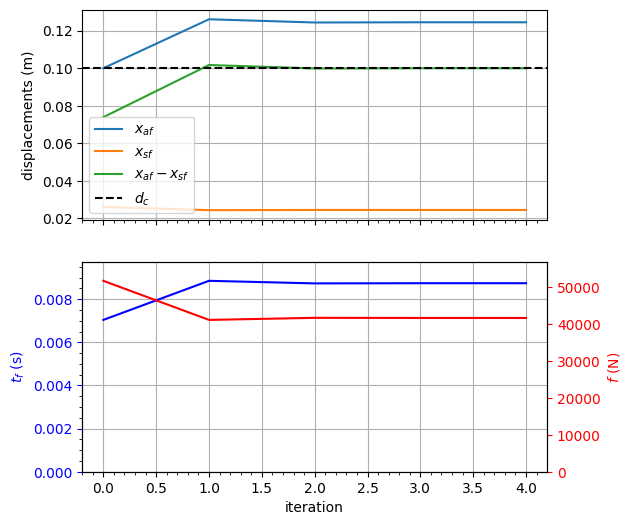

In [202]:
n_iter = 5

k_s_ = 1693141.8112   # N/m
m_s_ = 30  # kg
c_s_ = 6411.6120  # Ns/m

cohesion = False

brick_area = 0.84*0.30
F_ = 5322676.007541873 

T_ = 0.00013695317789071088

x_s_max_hf = 0

m_a_ = 2 * brick_area * 0.0032 * 7850
print(f'{m_a_=} kg')

d_c_ = 0.10

# Assuming the loading is a triangle, duration must be halved because x_s_max assumes a rectangular pulse
print(f'Loading: {F_=:4f} N, {T_=:4f} s')
print(f'Baseline: {x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=:4f} m') # assume no cohesion for structure alone


# Call interative optimization
x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_ = iter_opt(n_iter, k_s_, c_s_, m_s_, F_, T_, m_a_, d_c_,
                                                              cohesion=cohesion)

full_iters_max_press.append(FullIter(k_s_, m_s_, c_s_, cohesion, brick_area, F_, T_, m_a_, d_c_, x_s_max_hf,
                           IterOptResults(x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_)))
full_iters_max_press[-1].iter_opt_results.plot(d_c_)

### full_iter = 1

12.660480000000002
Loading: F_=11372445.798035 N, T_=0.000086 s
Baseline: x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=0.016875 m
x_s_f_=0.000001, x_a_f_=0.100001, (x_a_f_-x_s_f_)=0.100000, t_f_=0.000861, f_=0.000001, x_s_max_=0.000000
x_s_f_=0.008351, x_a_f_=0.108351, (x_a_f_-x_s_f_)=0.100000, t_f_=0.005228, f_=93675.794169, x_s_max_=0.008351
x_s_f_=0.007714, x_a_f_=0.107714, (x_a_f_-x_s_f_)=0.100000, t_f_=0.005660, f_=86529.681169, x_s_max_=0.007714
x_s_f_=0.007759, x_a_f_=0.107759, (x_a_f_-x_s_f_)=0.100000, t_f_=0.005627, f_=87036.248479, x_s_max_=0.007759
x_s_f_=0.007756, x_a_f_=0.107756, (x_a_f_-x_s_f_)=0.100000, t_f_=0.005629, f_=87000.144148, x_s_max_=0.007756


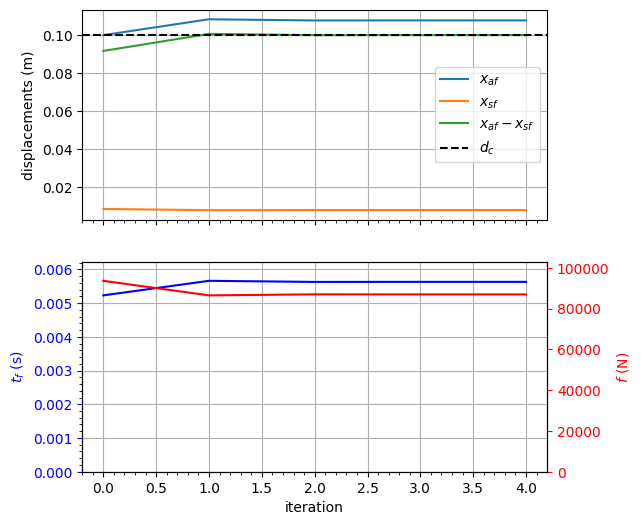

In [203]:
n_iter = 5

k_s_ = 21893961.8663 # N/m
m_s_ = 36.6332  # kg
c_s_ = 888.9258 # Ns/m

cohesion = False

brick_area = 0.84*0.3
F_ = 11372445.798035474

T_ = 8.612517950101458e-05

x_s_max_hf = 0

m_a_ = 2 * brick_area * 0.0032 * 7850
print(m_a_)

d_c_ = 0.10

# Assuming the loading is a triangle, duration must be halved because x_s_max assumes a rectangular pulse
print(f'Loading: {F_=:4f} N, {T_=:4f} s')
print(f'Baseline: {x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=:4f} m') # assume no cohesion for structure alone


# Call interative optimization
x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_ = iter_opt(n_iter, k_s_, c_s_, m_s_, F_, T_, m_a_, d_c_,
                                                              cohesion=cohesion)

full_iters_max_press.append(FullIter(k_s_, m_s_, c_s_, cohesion, brick_area, F_, T_, m_a_, d_c_, x_s_max_hf,
                                     IterOptResults(x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_)))
full_iters_max_press[-1].iter_opt_results.plot(d_c_)

### full_iter = 2

12.660480000000002
Loading: F_=11372438.495168 N, T_=0.000087 s
Baseline: x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=0.016149 m
x_s_f_=0.000001, x_a_f_=0.100001, (x_a_f_-x_s_f_)=0.100000, t_f_=0.000873, f_=0.000001, x_s_max_=0.000000
x_s_f_=0.013381, x_a_f_=0.113381, (x_a_f_-x_s_f_)=0.100000, t_f_=0.005161, f_=96154.406629, x_s_max_=0.013381
x_s_f_=0.012783, x_a_f_=0.112783, (x_a_f_-x_s_f_)=0.100000, t_f_=0.005844, f_=84920.222382, x_s_max_=0.012783
x_s_f_=0.012810, x_a_f_=0.112810, (x_a_f_-x_s_f_)=0.100000, t_f_=0.005813, f_=85366.192999, x_s_max_=0.012810
x_s_f_=0.012809, x_a_f_=0.112809, (x_a_f_-x_s_f_)=0.100000, t_f_=0.005814, f_=85346.015038, x_s_max_=0.012809


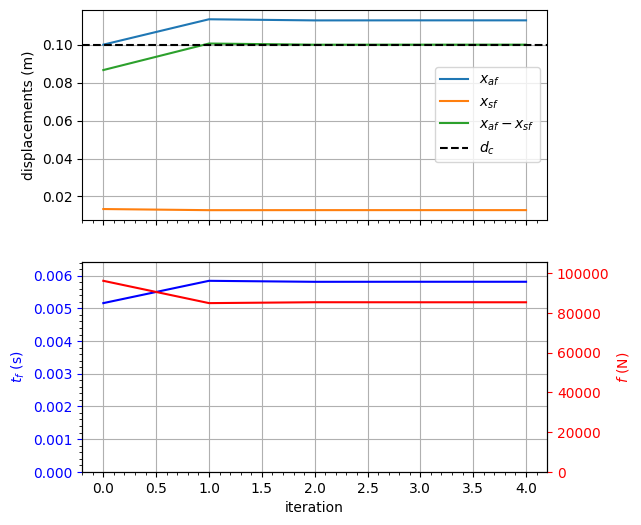

In [205]:
n_iter = 5

k_s_ = 4939399.4284 # N/m
m_s_ = 25.8877 # kg
c_s_ = 22603.9270 # Ns/m

cohesion = False

brick_area = 0.84*0.3
F_ = 11372438.495167615

T_ = 8.727003247778969e-05

x_s_max_hf = 0

m_a_ = 2 * brick_area * 0.0032 * 7850
print(m_a_)

d_c_ = 0.10

# Assuming the loading is a triangle, duration must be halved because x_s_max assumes a rectangular pulse
print(f'Loading: {F_=:4f} N, {T_=:4f} s')
print(f'Baseline: {x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=:4f} m') # assume no cohesion for structure alone


# Call interative optimization
x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_ = iter_opt(n_iter, k_s_, c_s_, m_s_, F_, T_, m_a_, d_c_,
                                                              cohesion=cohesion)

full_iters_max_press.append(FullIter(k_s_, m_s_, c_s_, cohesion, brick_area, F_, T_, m_a_, d_c_, x_s_max_hf,
                           IterOptResults(x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_)))
full_iters_max_press[-1].iter_opt_results.plot(d_c_)

### Convergence Analysis

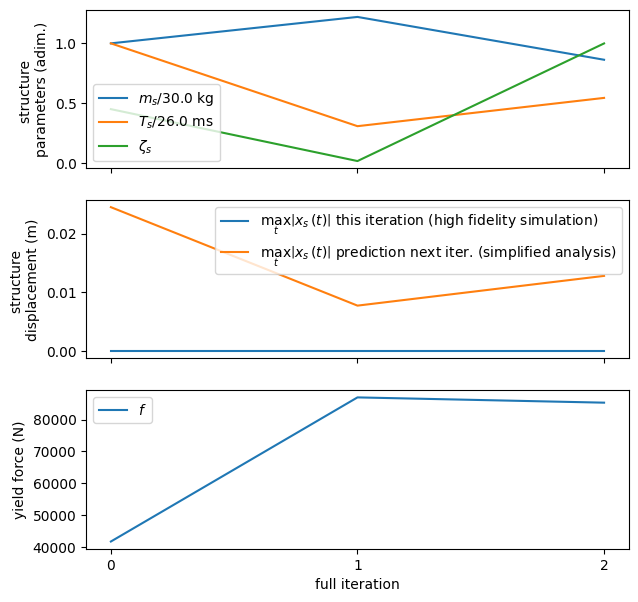

In [234]:
from typing import List


def convergence_analysis(full_iters: List[FullIter]):
    m_s_iters, omega_s_iters, period_s_iters, zeta_s_iters, x_s_max_hf_iters = [], [], [], [], []
    x_s_max_iters, f_iters = [], []
    
    for full_iter in full_iters:
        omega_rad_s = np.sqrt(full_iter.k_s_/full_iter.m_s_)
        m_s_iters.append(full_iter.m_s_)
        omega_s_iters.append(omega_rad_s)
        period_s_iters.append(1/(omega_rad_s/(2*np.pi)))
        zeta_s_iters.append((full_iter.c_s_)/(2*(full_iter.m_s_)*omega_rad_s))
        x_s_max_iters.append(full_iter.iter_opt_results.x_s_max_)
        f_iters.append(full_iter.iter_opt_results.f_list[-1])
        x_s_max_hf_iters.append(full_iter.x_s_max_hf)

    m_s_iters = np.array(m_s_iters)
    omega_s_iters = np.array(omega_s_iters)
    period_s_iters = np.array(period_s_iters)
    zeta_s_iters = np.array(zeta_s_iters)
    x_s_max_iters = np.array(x_s_max_iters)
    f_iters = np.array(f_iters)

    fig, ax = plt.subplots(3, 1, sharex='col', figsize=(7,7))
    ax[0].plot(m_s_iters/m_s_iters[0], label=f'$m_s / ${np.round(m_s_iters[0])} kg')
    ax[0].plot(period_s_iters/period_s_iters[0], label=f'$T_s / ${np.round(1e3*period_s_iters[0])} ms')
    ax[0].plot(zeta_s_iters, label=r'$\zeta_s$')
    ax[0].set_ylabel('structure \nparameters (adim.)')
    ax[0].legend()

    ax[1].plot(x_s_max_hf_iters, label=r'$\max_{t}{\left|x_s(t)\right|}$ this iteration (high fidelity simulation)')
    ax[1].plot(x_s_max_iters, label=r'$\max_{t}{\left|x_s(t)\right|}$ prediction next iter. (simplified analysis)')
    ax[1].set_ylabel('structure \ndisplacement (m)')
    ax[1].legend()

    ax[2].plot(f_iters, label=r'$f$')
    ax[2].set_ylabel('yield force (N)')
    ax[2].legend()
    ax[-1].set_xticks(range(len(m_s_iters)), range(len(m_s_iters)))
    ax[-1].set_xlabel('full iteration')
    plt.show()

convergence_analysis(full_iters_max_press)

# Hypothesis: Mean pressure applied to all the area

In [221]:
full_iters_mean_press = []

### full_iter = 0

m_a_=12.660480000000002 kg
Loading: F_=1753384.957032 N, T_=0.000265 s
Baseline: x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=0.029496 m
x_s_f_=0.000001, x_a_f_=0.100001, (x_a_f_-x_s_f_)=0.100000, t_f_=0.002647, f_=0.000001, x_s_max_=0.000000
x_s_f_=0.022084, x_a_f_=0.122084, (x_a_f_-x_s_f_)=0.100000, t_f_=0.011088, f_=20929.412340, x_s_max_=0.022084
x_s_f_=0.019266, x_a_f_=0.119266, (x_a_f_-x_s_f_)=0.100000, t_f_=0.013497, f_=17193.162728, x_s_max_=0.019266
x_s_f_=0.019629, x_a_f_=0.119629, (x_a_f_-x_s_f_)=0.100000, t_f_=0.013190, f_=17593.963175, x_s_max_=0.019629
x_s_f_=0.019582, x_a_f_=0.119582, (x_a_f_-x_s_f_)=0.100000, t_f_=0.013230, f_=17541.220278, x_s_max_=0.019582


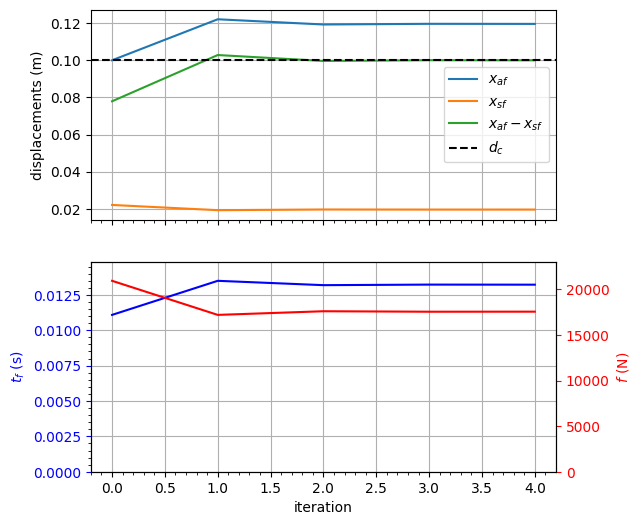

In [222]:
n_iter = 5

k_s_ = 1042199.4336   # N/m
m_s_ = 18.4025  # kg
c_s_ = 4206.8071  # Ns/m

cohesion = False

brick_area = 0.84*0.30
F_ = 1753384.9570321564

T_ = 0.00026470203578144846

x_s_max_hf = 0.030513471603

m_a_ = 2 * brick_area * 0.0032 * 7850
print(f'{m_a_=} kg')

d_c_ = 0.10

# Assuming the loading is a triangle, duration must be halved because x_s_max assumes a rectangular pulse
print(f'Loading: {F_=:4f} N, {T_=:4f} s')
print(f'Baseline: {x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=:4f} m') # assume no cohesion for structure alone


# Call interative optimization
x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_ = iter_opt(n_iter, k_s_, c_s_, m_s_, F_, T_, m_a_, d_c_,
                                                              cohesion=cohesion)

full_iters_mean_press.append(FullIter(k_s_, m_s_, c_s_, cohesion, brick_area, F_, T_, m_a_, d_c_, x_s_max_hf,
                           IterOptResults(x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_)))
full_iters_mean_press[-1].iter_opt_results.plot(d_c_)

### full_iter = 1

12.660480000000002
Loading: F_=2980279.138698 N, T_=0.000187 s
Baseline: x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=0.011362 m
x_s_f_=0.000001, x_a_f_=0.100001, (x_a_f_-x_s_f_)=0.100000, t_f_=0.001867, f_=0.000001, x_s_max_=0.000000
x_s_f_=0.003417, x_a_f_=0.103417, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009225, f_=30162.141970, x_s_max_=0.003417
x_s_f_=0.003306, x_a_f_=0.103306, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009536, f_=29178.874634, x_s_max_=0.003306
x_s_f_=0.003309, x_a_f_=0.103309, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009526, f_=29209.925695, x_s_max_=0.003309
x_s_f_=0.003309, x_a_f_=0.103309, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009526, f_=29208.944108, x_s_max_=0.003309


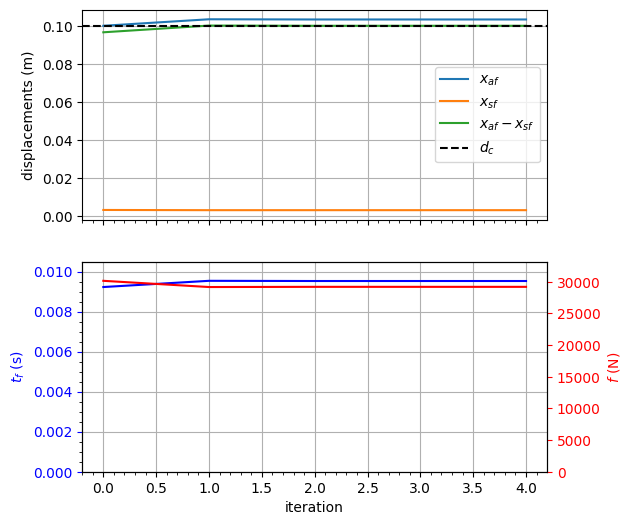

In [223]:
n_iter = 5

k_s_ = 17081238.2460 # N/m
m_s_ = 32.8447 # kg
c_s_ = 1012.4022 # Ns/m

cohesion = False

brick_area = 0.84*0.3
F_ = 2980279.138698474

T_ = 0.0001867224575098225

x_s_max_hf = 0.011924426873897219

m_a_ = 2 * brick_area * 0.0032 * 7850
print(m_a_)

d_c_ = 0.10

# Assuming the loading is a triangle, duration must be halved because x_s_max assumes a rectangular pulse
print(f'Loading: {F_=:4f} N, {T_=:4f} s')
print(f'Baseline: {x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=:4f} m') # assume no cohesion for structure alone


# Call interative optimization
x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_ = iter_opt(n_iter, k_s_, c_s_, m_s_, F_, T_, m_a_, d_c_,
                                                              cohesion=cohesion)

full_iters_mean_press.append(FullIter(k_s_, m_s_, c_s_, cohesion, brick_area, F_, T_, m_a_, d_c_, x_s_max_hf,
                                     IterOptResults(x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_)))
full_iters_mean_press[-1].iter_opt_results.plot(d_c_)

### full_iter = 2

12.660480000000002
Loading: F_=2988228.603234 N, T_=0.000189 s
Baseline: x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=0.010751 m
x_s_f_=0.000001, x_a_f_=0.100001, (x_a_f_-x_s_f_)=0.100000, t_f_=0.001892, f_=0.000001, x_s_max_=0.000000
x_s_f_=0.003004, x_a_f_=0.103004, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009082, f_=31134.689085, x_s_max_=0.003004
x_s_f_=0.002918, x_a_f_=0.102918, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009350, f_=30239.127795, x_s_max_=0.002918
x_s_f_=0.002920, x_a_f_=0.102920, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009343, f_=30264.175907, x_s_max_=0.002920
x_s_f_=0.002920, x_a_f_=0.102920, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009343, f_=30263.474767, x_s_max_=0.002920


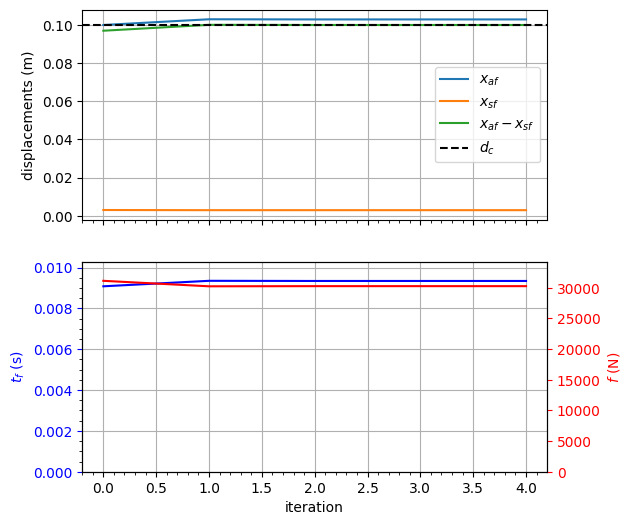

In [224]:
n_iter = 5

k_s_ = 20010937.4938 # N/m
m_s_ = 32.1956 # kg
c_s_ = 1155.6621 # Ns/m

cohesion = False
brick_area = 0.84*0.3
F_ = 2988228.6032344867

T_ = 0.00018924241894998354

x_s_max_hf = 0.005660694898704745

m_a_ = 2 * brick_area * 0.0032 * 7850
print(m_a_)

d_c_ = 0.10

# Assuming the loading is a triangle, duration must be halved because x_s_max assumes a rectangular pulse
print(f'Loading: {F_=:4f} N, {T_=:4f} s')
print(f'Baseline: {x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=:4f} m') # assume no cohesion for structure alone


# Call interative optimization
x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_ = iter_opt(n_iter, k_s_, c_s_, m_s_, F_, T_, m_a_, d_c_,
                                                              cohesion=cohesion)

full_iters_mean_press.append(FullIter(k_s_, m_s_, c_s_, cohesion, brick_area, F_, T_, m_a_, d_c_, x_s_max_hf, 
                                     IterOptResults(x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_)))
full_iters_mean_press[-1].iter_opt_results.plot(d_c_)

### full_iter = 3

12.660480000000002
Loading: F_=2988228.603234 N, T_=0.000188 s
Baseline: x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=0.010703 m
x_s_f_=0.000001, x_a_f_=0.100001, (x_a_f_-x_s_f_)=0.100000, t_f_=0.001884, f_=0.000001, x_s_max_=0.000000
x_s_f_=0.002978, x_a_f_=0.102978, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009121, f_=30860.532593, x_s_max_=0.002978
x_s_f_=0.002893, x_a_f_=0.102893, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009389, f_=29980.315461, x_s_max_=0.002893
x_s_f_=0.002895, x_a_f_=0.102895, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009381, f_=30004.733368, x_s_max_=0.002895
x_s_f_=0.002895, x_a_f_=0.102895, (x_a_f_-x_s_f_)=0.100000, t_f_=0.009382, f_=30004.055460, x_s_max_=0.002895


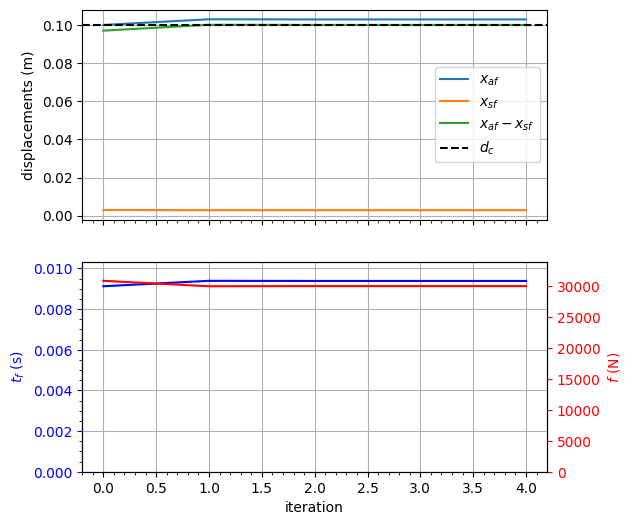

In [225]:
n_iter = 5

k_s_ = 20010174.4520 # N/m
m_s_ = 32.2000 # kg
c_s_ = 1155.7553 # Ns/m

cohesion = False

brick_area = 0.84*0.3
F_ = 2988228.6032344867

T_ = 0.0001883957047093658

x_s_max_hf = 0.005660694898704745

m_a_ = 2 * brick_area * 0.0032 * 7850
print(m_a_)

d_c_ = 0.10

# Assuming the loading is a triangle, duration must be halved because x_s_max assumes a rectangular pulse
print(f'Loading: {F_=:4f} N, {T_=:4f} s')
print(f'Baseline: {x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)=:4f} m') # assume no cohesion for structure alone


# Call interative optimization
x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_ = iter_opt(n_iter, k_s_, c_s_, m_s_, F_, T_, m_a_, d_c_,
                                                              cohesion=cohesion)

full_iters_mean_press.append(FullIter(k_s_, m_s_, c_s_, cohesion, brick_area, F_, T_, m_a_, d_c_, x_s_max_hf,
                                     IterOptResults(x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_)))
full_iters_mean_press[-1].iter_opt_results.plot(d_c_)

### Convergence

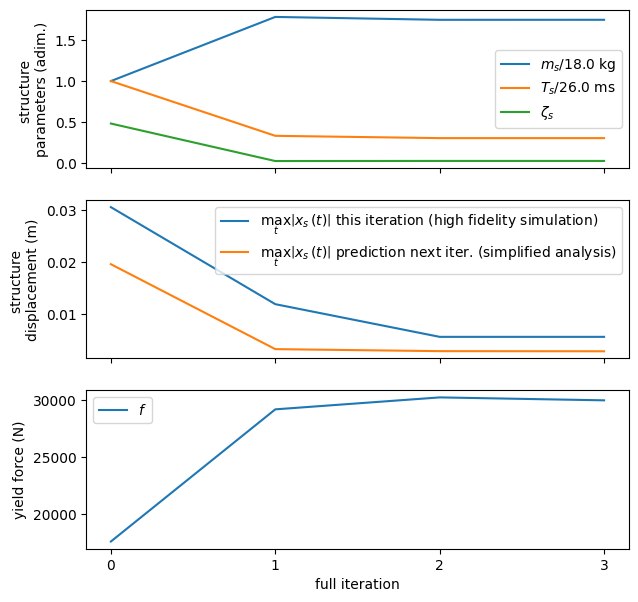

In [235]:
convergence_analysis(full_iters_mean_press)

# Apply analytic optimization to scenarios optimized by brute force

In [227]:
import pickle


# Brute force optimum results for comparison
with open('optimum_brute_force.pkl', 'rb') as file:
    (optimum_parameters, optimum_performance) = pickle.load(file=file)

# Analytically optimized results for comparison
with open('optimized.pkl', 'rb') as file:
    (optimized_parameters, optimized_performance) = pickle.load(file=file)

KeyboardInterrupt: 

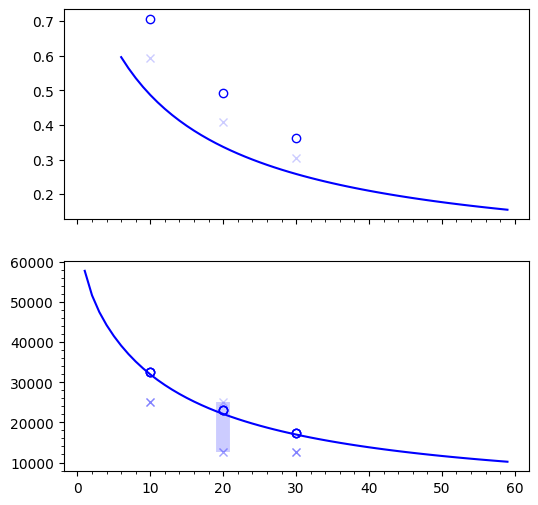

In [228]:
n_iter = 10

verbose = False
k_s_ = (57.6 * 2 / np.pi) * (2 * np.pi * 120) ** 2
m_s_ = 57.6 * 2 / np.pi
c_s_ = 0

fig, ax = plt.subplots(2, 1, figsize=(6,6), sharex='col')
plt.minorticks_on()

load_factor_values = [0.5, 1.0, 2.0]
colors_load_factor = {0.5: 'blue', 1.0: 'red', 2.0: 'green'}

for load_factor in load_factor_values:
    brick_area = 0.23*0.24
    F_ = 10e6*.294*brick_area * load_factor
    T_ = 5e-3
    m_a_values = range(1, 60, 1)

    # Assuming the loading is a triangle, duration must be halved because x_s_max asumes a rectangular pulse
    baseline = x_s_max(m_s_, c_s_, k_s_, T_/2, F_, cohesion=False)

    performance, parameter_f = [], []
    for m_a_ in m_a_values:

        d_c_ = 0.05*.55

        if verbose:
            print(f'{m_a_=} kg')
            print(f'Loading: {F_=:4f} N, {T_=:4f} s')
            print(f'Baseline: {baseline=:4f} m')

        x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_ = iter_opt(n_iter, k_s_, c_s_, m_s_, F_, T_, m_a_, d_c_, 
                                                                      cohesion=True, verbose=verbose)

        performance.append(x_s_max_/baseline)
        parameter_f.append(f_list[-1])

        try:
            if m_a_ == 30:
                label_bf = 'BF opt.'
                label_anal = 'A. opt.'
            else:
                label_bf = label_anal = None

            ax[0].plot(m_a_, optimum_performance[load_factor][int(m_a_)], linestyle='none', marker='x', 
                       color=colors_load_factor[load_factor], label=label_bf, alpha=0.2)
            ax[1].plot(m_a_ * np.ones_like(optimum_parameters[load_factor][int(m_a_)][3:]), 
                       optimum_parameters[load_factor][int(m_a_)][3:], linestyle='--', marker='x', 
                       color=colors_load_factor[load_factor], label=label_bf, alpha=0.2, linewidth=10.)
            
            ax[0].plot(m_a_, optimized_performance[load_factor][int(m_a_)], linestyle='none', marker='o', 
                       color=colors_load_factor[load_factor], fillstyle='none', label=label_anal)
            ax[1].plot(m_a_ * np.ones_like(optimized_parameters[load_factor][int(m_a_)][3:]), 
                       optimized_parameters[load_factor][int(m_a_)][3:], linestyle='none', marker='o', 
                       color=colors_load_factor[load_factor], fillstyle='none', label=label_anal)

        except KeyError:
            pass

    ax[0].plot(m_a_values, performance, color=colors_load_factor[load_factor], label=f'$F/F_0$={load_factor}')
    ax[1].plot(m_a_values, parameter_f, color=colors_load_factor[load_factor])

ax[0].set_ylabel(r'$\frac{\max_{t} (x_{s}) }{ \max_{t} (x_{s0}) } $')
ax[0].set_title('(a)', loc='left')
ax[0].legend(loc='right')
ax[0].set_ylim([0.1, 1.1])
# ax[0].set_yscale('log')
ax[0].set_title('(a)', loc='left')
ax[0].grid()

ax[1].set_xlabel(r'$m_a$ (kg)')
ax[1].set_yscale('log')
ax[1].set_ylabel(r'$f$ (N)')
ax[1].set_title(r'(b)', loc='left')
ax[1].grid()            

plt.show()